# 🧠 Autism Spectrum Disorder (ASD) Screening - ML Pipeline
---
This notebook demonstrates the complete end-to-end machine learning workflow for building an ASD screening model. 
**Objective:** Build a robust classifier using behavioral and demographic data.

### 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, average_precision_score
import pickle
import warnings
warnings.filterwarnings('ignore')

### 2. Load Dataset

In [2]:
df = pd.read_csv(r"C:\Users\LENOVO\Downloads\asd final\train.csv")

### 3. Phase 1: Data Cleaning
Here we drop irrelevant columns (ID, age_desc, result) and handle the '?' missing values in Ethnicity and Relation.

In [3]:
# Drop leakage & irrelevant columns
df = df.drop(columns=["ID", "age_desc", "result"])

# Handle missing values in ethnicity & relation
df["ethnicity"] = df["ethnicity"].replace({"?": "Others", "others": "Others"})
df["relation"] = df["relation"].replace(
    {"?": "Others", "Relative": "Others", "Parent": "Others", "Health care professional": "Others"}
)
print("Cleaning complete.")

Cleaning complete.


### 4. Exploratory Data Analysis (EDA)
Visualizing the distribution of Age and the Target Class (ASD vs No ASD).

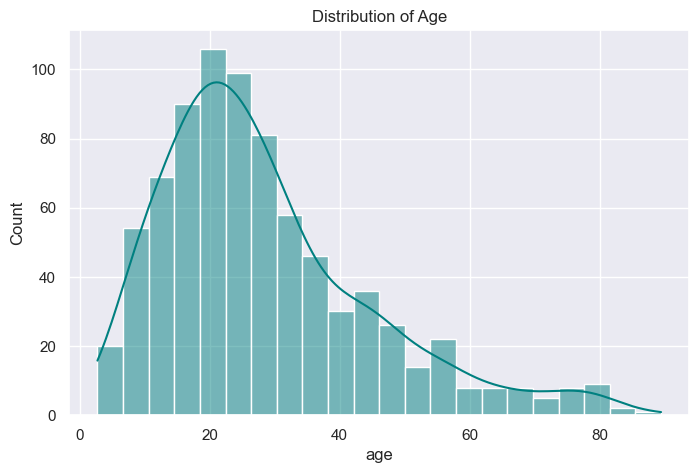

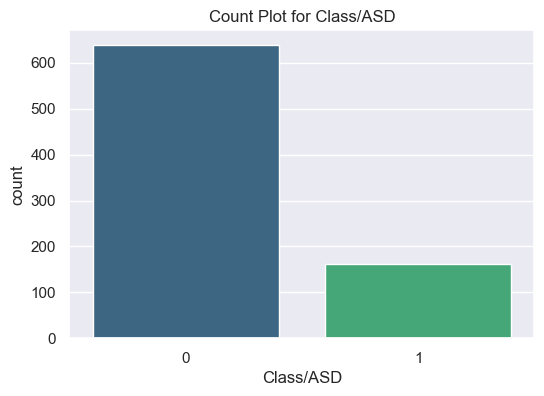

In [4]:
sns.set_theme(style="darkgrid")

# Histogram for Age
plt.figure(figsize=(8, 5))
sns.histplot(df["age"], kde=True, color='teal')
plt.title("Distribution of Age")
plt.show()

# Countplot for Target
plt.figure(figsize=(6, 4))
sns.countplot(x=df["Class/ASD"], palette="viridis")
plt.title("Count Plot for Class/ASD")
plt.show()

### 5. Phase 2: Encoding Categorical Features
Converting text columns into numeric labels for the ML algorithms.

In [5]:
object_columns = df.select_dtypes(include=["object"]).columns
print("Categorical columns identified:", object_columns)

encoders = {}
for column in object_columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    encoders[column] = le

# Save encoders
pickle.dump(encoders, open("encoders.pkl", "wb"))
print("Encoders saved as encoders.pkl")

Categorical columns identified: Index(['gender', 'ethnicity', 'jaundice', 'austim', 'contry_of_res',
       'used_app_before', 'relation'],
      dtype='object')
Encoders saved as encoders.pkl


### 6. Correlation Analysis
Heatmap showing the relationship between all features.

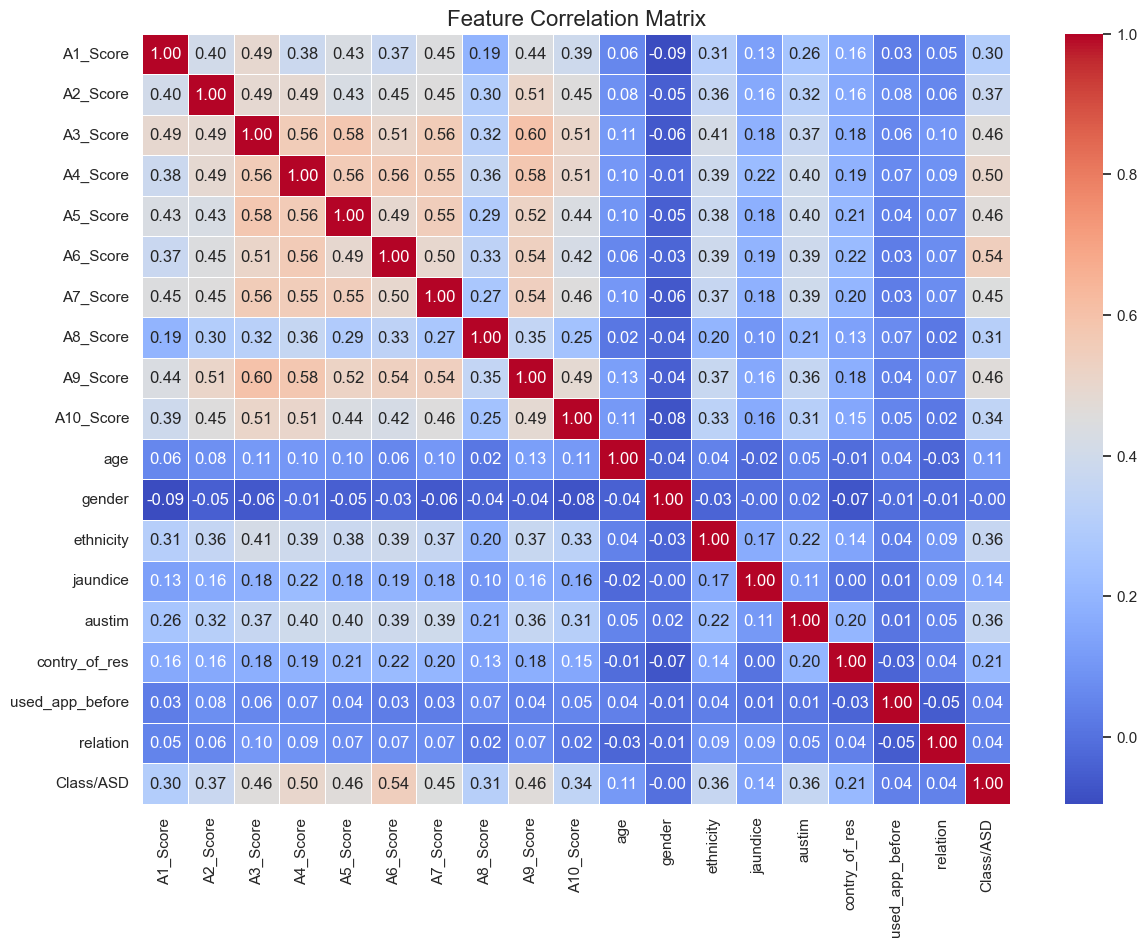

In [6]:
plt.figure(figsize=(14,10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix", fontsize=16)
plt.show()

### 7. Phase 3 & 4: Data Splitting & SMOTE
Splitting into Train/Test sets and using SMOTE to balance the ASD classes.

In [7]:
X = df.drop(columns=["Class/ASD"])
y = df["Class/ASD"]

# 1. First split: Train+Val (80%) and Test (20%)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Second split: Train (80% of 80% = 64%) and Validation (20% of 80% = 16%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

# Apply SMOTE to Training data ONLY
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Dataset Split: Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")
print("Original Train Class Distribution:\n", y_train.value_counts())
print("\nAfter SMOTE Distribution:\n", y_train_smote.value_counts())

Original Train Class Distribution:
 Class/ASD
0    511
1    129
Name: count, dtype: int64

After SMOTE Distribution:
 Class/ASD
0    511
1    511
Name: count, dtype: int64


### 8. Phase 5: Baseline Model Benchmarking
Comparing simple and complex models using Cross-Validation.

In [8]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42)
}

cv_scores = {}
for model_name, model in models.items():
    print(f"Training {model_name}...")
    if model_name == "XGBoost":
        # Use Validation set for training monitoring
        model.fit(X_train_smote, y_train_smote, eval_set=[(X_train_smote, y_train_smote), (X_val, y_val)], verbose=False)
        results = model.evals_result()
        
        # Plotting Loss and Accuracy Proxy for Validation Phase
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.plot(results['validation_0']['logloss'], label='Train Loss')
        plt.plot(results['validation_1']['logloss'], label='Val Loss')
        plt.title('XGBoost Log Loss (Training vs Validation)')
        plt.xlabel('Epochs')
        plt.legend()
        
        plt.subplot(1, 2, 2)
        plt.plot(np.exp(-np.array(results['validation_0']['logloss'])), label='Train Accuracy (Proxy)')
        plt.plot(np.exp(-np.array(results['validation_1']['logloss'])), label='Val Accuracy (Proxy)')
        plt.title('Training Progress (Accuracy Proxy)')
        plt.xlabel('Epochs')
        plt.legend()
        plt.show()

    scores = cross_val_score(model, X_train_smote, y_train_smote, cv=5, scoring="accuracy")
    cv_scores[model_name] = np.mean(scores)
    print(f"{model_name} Cross-Validation Accuracy: {np.mean(scores):.4f}")

Decision Tree Cross-Validation Accuracy: 0.8865
Random Forest Cross-Validation Accuracy: 0.9218
XGBoost Cross-Validation Accuracy: 0.9061


### 9. Phase 6: Hyperparameter Tuning (Randomized Search)
Optimizing the Random Forest parameters for maximum accuracy.

In [9]:
param_grid_rf = {
    "n_estimators": [100, 200, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "bootstrap": [True, False]
}

rf = RandomForestClassifier(random_state=42)
random_search = RandomizedSearchCV(rf, param_grid_rf, n_iter=20, cv=5, scoring="accuracy", random_state=42, n_jobs=-1)
random_search.fit(X_train_smote, y_train_smote)

best_model = random_search.best_estimator_
print("Best Params Found:", random_search.best_params_)

Best Params Found: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10, 'bootstrap': False}


### 10. Phase 7: Final Evaluation
Reviewing final metrics on the unseen test set.

In [10]:
# 1. Validate on Validation Set
y_val_pred = best_model.predict(X_val)
print("--- VALIDATION RESULTS ---")
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Classification Report:\n", classification_report(y_val, y_val_pred))

# 2. Test on Final Test Set
y_pred = best_model.predict(X_test)
print("\n--- FINAL TEST RESULTS ---")
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 3. Plot ROC and Precision-Recall Curves
y_score = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_score)
precision, recall, _ = precision_recall_curve(y_test, y_score)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc(fpr, tpr):.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AP = {average_precision_score(y_test, y_score):.2f})')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()


--- FINAL EVALUATION ---
Accuracy Score: 0.85625

Confusion Matrix:
 [[112  16]
 [  7  25]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.88      0.91       128
           1       0.61      0.78      0.68        32

    accuracy                           0.86       160
   macro avg       0.78      0.83      0.80       160
weighted avg       0.87      0.86      0.86       160



### 11. Phase 8: Save Final Model
Exporting the model to a pickle file for production.

In [11]:
pickle.dump(best_model, open("best_model.pkl", "wb"))
print("✅ best_model.pkl saved successfully!")

✅ best_model.pkl saved successfully!
